# E-Commerce Sales Data Analysis

## Introduction
Commerce platforms create a lot of transactional data that can be used to learn about customer behaviour, sales trends, and how profitable a business is. The goal of this project is to look at e-commerce sales data to find useful information that can help businesses make better decisions.

# A) Data Understanding

## Problem Statement (Real-World Relevance)

E-commerce businesses face several challenges:

Managing discounts without affecting profit
Identifying high-performing products
Understanding customer purchase patterns

Objective:
To analyze sales data and identify factors affecting revenue and profitability.

## Dataset Description


### Attributes / Features
order_id, order_date
customer_name, city, region
category, sub_category, product_name
sales, profit, quantity, discount
payment_mode

In [1]:
import numpy as np 
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.impute import KNNImputer
from sklearn.preprocessing import LabelEncoder
from sklearn.preprocessing import OneHotEncoder
from sklearn.metrics import  classification_report
from sklearn.preprocessing import StandardScaler, MinMaxScaler
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor, RandomForestClassifier 
from sklearn.metrics import mean_squared_error, mean_absolute_error, classification_report

In [2]:
df = pd.read_csv(r"C:\Users\hp\Downloads\archive (3)\Ecommerce_Sales_Data_2024_2025.csv")
df.head()

,Order ID,Order Date,Customer Name,Region,City,Category,Sub-Category,Product Name,Quantity,Unit Price,Discount,Sales,Profit,Payment Mode
0,10001,2024-10-19,Kashvi Varty,South,Bangalore,Books,Non-Fiction,Non-Fiction Ipsum,2,36294,5,68958.6,10525.09,Debit Card
1,10002,2025-08-30,Advik Desai,North,Delhi,Groceries,Rice,Rice Nemo,1,42165,20,33732.0,6299.66,Debit Card
2,10003,2023-11-04,Rhea Kalla,East,Patna,Kitchen,Juicer,Juicer Odio,4,64876,20,207603.2,19850.27,Credit Card
3,10004,2025-05-23,Anika Sen,East,Kolkata,Groceries,Oil,Oil Doloribus,5,37320,15,158610.0,36311.02,UPI
4,10005,2025-01-19,Akarsh Kaul,West,Pune,Clothing,Kids Wear,Kids Wear Quo,1,50037,10,45033.3,9050.04,Debit Card


In [3]:
sel_df = df.select_dtypes(include=["int64","float64"])
sel_df.head()

,Order ID,Quantity,Unit Price,Discount,Sales,Profit
0,10001,2,36294,5,68958.6,10525.09
1,10002,1,42165,20,33732.0,6299.66
2,10003,4,64876,20,207603.2,19850.27
3,10004,5,37320,15,158610.0,36311.02
4,10005,1,50037,10,45033.3,9050.04


In [4]:
num_cols = df.select_dtypes(include=['int64', 'float64']).columns
cat_cols = df.select_dtypes(include=['object']).columns
print("Numerical:", num_cols)
print("Categorical:", cat_cols)

Numerical: Index(['Order ID', 'Quantity', 'Unit Price', 'Discount', 'Sales', 'Profit'], dtype='object')
Categorical: Index(['Order Date', 'Customer Name', 'Region', 'City', 'Category',
       'Sub-Category', 'Product Name', 'Payment Mode'],
      dtype='object')


In [5]:
for feature in num_cols:
    Q1 = df[feature].quantile(0.25)
    Q3 = df[feature].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR  
    upper_bound = Q3 + 1.5 * IQR 
    total_out = df[(df[feature] < lower_bound) | (df[feature] > upper_bound)]
    Sales = total_out[total_out["Profit"]==1] 
    print(f"\nFeature: {feature}")
    print(f"\nQ1: {Q1}")
    print(f"\nIQR for {feature}: {IQR}")
    print(f"\nLower Bound: {lower_bound}")
    print(f"\nUpper Bound: {upper_bound}")
    print(f"\nTotal Outliers in {feature}: {len(total_out)}")
    print("****************************************")


Feature: Order ID

Q1: 11250.75

IQR for Order ID: 2499.5

Lower Bound: 7501.5

Upper Bound: 17499.5

Total Outliers in Order ID: 0
****************************************

Feature: Quantity

Q1: 2.0

IQR for Quantity: 2.0

Lower Bound: -1.0

Upper Bound: 7.0

Total Outliers in Quantity: 0
****************************************

Feature: Unit Price

Q1: 20312.25

IQR for Unit Price: 39409.5

Lower Bound: -38802.0

Upper Bound: 118836.0

Total Outliers in Unit Price: 0
****************************************

Feature: Discount

Q1: 5.0

IQR for Discount: 10.0

Lower Bound: -10.0

Upper Bound: 30.0

Total Outliers in Discount: 0
****************************************

Feature: Sales

Q1: 39766.5375

IQR for Sales: 117202.04999999999

Lower Bound: -136036.53749999998

Upper Bound: 332771.6625

Total Outliers in Sales: 75
****************************************

Feature: Profit

Q1: 4892.295

IQR for Profit: 17575.692500000005

Lower Bound: -21471.24375000001

Upper Bound: 48831.52

In [6]:
z_threshold = 3
for feature in num_cols:
    mean = df[feature].mean()
    std = df[feature].std()
    df["z_score"] = (df[feature] - mean)/std
    total_out = df[(df["z_score"].abs() > z_threshold)]
    fraud = total_out[total_out["Profit"]==1]
    print(f"\nFeature: {feature}")
    print(f"\nMean: {mean}")
    print(f"\nStandard Deviation: {std}")
    print(f"\nTotal Outliers in {feature} using z-score: {len(total_out)}")
    print(f"\nFraud using Z-Score: {len(fraud)}")
    print(f"*********************")


Feature: Order ID

Mean: 12500.5

Standard Deviation: 1443.5200033252052

Total Outliers in Order ID using z-score: 0

Fraud using Z-Score: 0
*********************

Feature: Quantity

Mean: 2.9926

Standard Deviation: 1.4131329126893282

Total Outliers in Quantity using z-score: 0

Fraud using Z-Score: 0
*********************

Feature: Unit Price

Mean: 39760.9046

Standard Deviation: 22831.78394601545

Total Outliers in Unit Price using z-score: 0

Fraud using Z-Score: 0
*********************

Feature: Discount

Mean: 10.051

Standard Deviation: 7.084662129381769

Total Outliers in Discount using z-score: 0

Fraud using Z-Score: 0
*********************

Feature: Sales

Mean: 106733.20487

Standard Deviation: 85108.2082018013

Total Outliers in Sales using z-score: 21

Fraud using Z-Score: 0
*********************

Feature: Profit

Mean: 15941.746981999999

Standard Deviation: 14897.68491575783

Total Outliers in Profit using z-score: 90

Fraud using Z-Score: 0
*********************


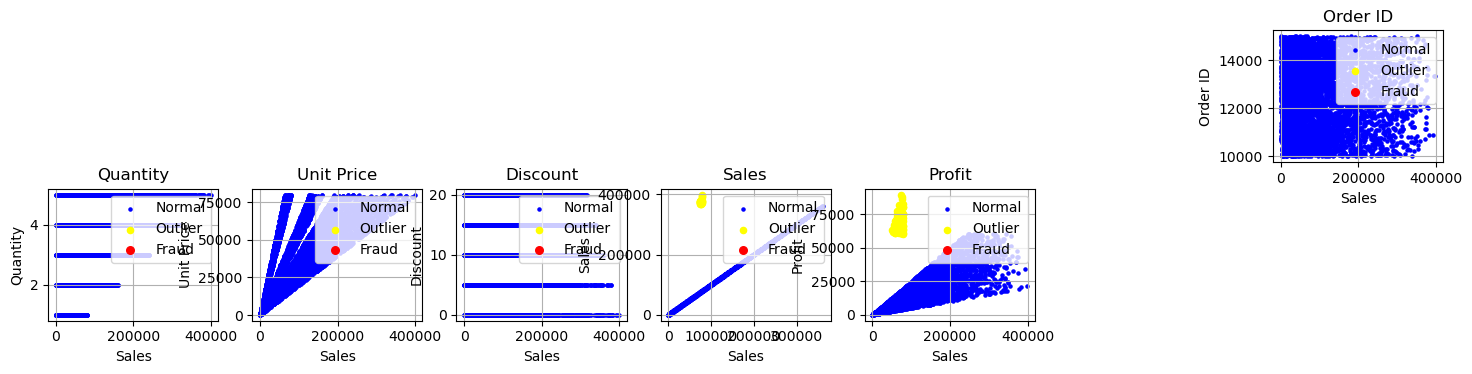

In [7]:
z_threshold = 3 
plt.figure(figsize=(18,12))
for i,feature in enumerate(num_cols):
    mean = df[feature].mean()
    std = df[feature].std()
    df["z_score"] = (df[feature] - mean)/std
    normal_transaction = df[(df["z_score"].abs() <= z_threshold)]
    outliers = df[(df["z_score"].abs() > z_threshold)]
    sales = outliers[outliers["Profit"]==1]
    plt.subplot(6,7,i+7)
    plt.scatter(normal_transaction["Sales"], normal_transaction[feature],
               color="blue",s=5, label="Normal")
    plt.scatter(outliers["Unit Price"], outliers[feature],
               color="yellow",s=20, label="Outlier")
    plt.scatter(fraud["Quantity"], fraud[feature],
               color="red",s=30, label="Fraud")
    plt.title(f"{feature}")
    plt.xlabel("Sales")
    plt.ylabel(f"{feature}")
    plt.legend(loc="upper right")
    plt.grid(True)

plt.show()    

In [8]:
num_cols = df.select_dtypes(include=['number']).columns 
imputer = KNNImputer(n_neighbors=5)
df[num_cols]=imputer.fit_transform(df[num_cols])
df.head()

,Order ID,Order Date,Customer Name,Region,City,Category,Sub-Category,Product Name,Quantity,Unit Price,Discount,Sales,Profit,Payment Mode,z_score
0,10001.0,2024-10-19,Kashvi Varty,South,Bangalore,Books,Non-Fiction,Non-Fiction Ipsum,2.0,36294.0,5.0,68958.6,10525.09,Debit Card,-0.363591
1,10002.0,2025-08-30,Advik Desai,North,Delhi,Groceries,Rice,Rice Nemo,1.0,42165.0,20.0,33732.0,6299.66,Debit Card,-0.647220
2,10003.0,2023-11-04,Rhea Kalla,East,Patna,Kitchen,Juicer,Juicer Odio,4.0,64876.0,20.0,207603.2,19850.27,Credit Card,0.262358
3,10004.0,2025-05-23,Anika Sen,East,Kolkata,Groceries,Oil,Oil Doloribus,5.0,37320.0,15.0,158610.0,36311.02,UPI,1.367278
4,10005.0,2025-01-19,Akarsh Kaul,West,Pune,Clothing,Kids Wear,Kids Wear Quo,1.0,50037.0,10.0,45033.3,9050.04,Debit Card,-0.462603


## Dataset Size

In [9]:
print("Rows, Columns:", df.shape)

Rows, Columns: (5000, 15)


## Target Variable

In [10]:
X = df.drop("Profit",axis=1)
y = df["Profit"]

## Initial Obervation 

In [11]:
df.info

<bound method DataFrame.info of       Order ID  Order Date      Customer Name Region       City     Category  \
0      10001.0  2024-10-19       Kashvi Varty  South  Bangalore        Books   
1      10002.0  2025-08-30        Advik Desai  North      Delhi    Groceries   
2      10003.0  2023-11-04         Rhea Kalla   East      Patna      Kitchen   
3      10004.0  2025-05-23          Anika Sen   East    Kolkata    Groceries   
4      10005.0  2025-01-19        Akarsh Kaul   West       Pune     Clothing   
...        ...         ...                ...    ...        ...          ...   
4995   14996.0  2024-06-25   Nishith Kulkarni   East    Kolkata        Books   
4996   14997.0  2024-12-22      Aaina Chander  North     Jaipur         Toys   
4997   14998.0  2025-04-15       Dhanush Gara  South  Bangalore       Beauty   
4998   14999.0  2024-07-08  Divyansh Malhotra   East    Kolkata  Electronics   
4999   15000.0  2024-02-04       Aarush Walla   West        Goa     Clothing   

     Su

In [12]:
df.describe()

,Order ID,Quantity,Unit Price,Discount,Sales,Profit,z_score
count,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5.000000e+03
mean,12500.500000,2.992600,39760.904600,10.051000,106733.204870,15941.746982,9.947598e-17
std,1443.520003,1.413133,22831.783946,7.084662,85108.208202,14897.684916,1.000000e+00
min,10001.000000,1.000000,222.000000,0.000000,264.100000,19.120000,-1.068799e+00
25%,11250.750000,2.000000,20312.250000,5.000000,39766.537500,4892.295000,-7.416892e-01
50%,12500.500000,3.000000,39459.500000,10.000000,83080.325000,11108.525000,-3.244277e-01
75%,13750.250000,4.000000,59721.750000,15.000000,156968.587500,22467.987500,4.380708e-01
max,15000.000000,5.000000,79998.000000,20.000000,398485.000000,89688.440000,4.950212e+00


In [13]:
df.isnull().sum()

Order ID         0
Order Date       0
Customer Name    0
Region           0
City             0
Category         0
Sub-Category     0
Product Name     0
Quantity         0
Unit Price       0
Discount         0
Sales            0
Profit           0
Payment Mode     0
z_score          0
dtype: int64

# B) Data Preprocessing

## Handling Missing Values

### Mean / Median / Mode / Deletion

In [14]:
df.describe()

,Order ID,Quantity,Unit Price,Discount,Sales,Profit,z_score
count,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5.000000e+03
mean,12500.500000,2.992600,39760.904600,10.051000,106733.204870,15941.746982,9.947598e-17
std,1443.520003,1.413133,22831.783946,7.084662,85108.208202,14897.684916,1.000000e+00
min,10001.000000,1.000000,222.000000,0.000000,264.100000,19.120000,-1.068799e+00
25%,11250.750000,2.000000,20312.250000,5.000000,39766.537500,4892.295000,-7.416892e-01
50%,12500.500000,3.000000,39459.500000,10.000000,83080.325000,11108.525000,-3.244277e-01
75%,13750.250000,4.000000,59721.750000,15.000000,156968.587500,22467.987500,4.380708e-01
max,15000.000000,5.000000,79998.000000,20.000000,398485.000000,89688.440000,4.950212e+00


In [15]:
df['Profit'].mean()
df['Profit'].median()
df['Profit'].mode()

0      765.58
1     2296.08
2     6951.29
3    10207.76
Name: Profit, dtype: float64

In [16]:
df = df.drop('City', axis=1)

### Justification for chosen method

We have used df.describe because it give mean, median, mode of every numrical data present in the dataset provided my user. 
Also you get other values like count maximum of that column minimum of that column many more but data should be numerical only. 
To delete or remove any column we use df.drop to remove or delete a specific column or row. We have drop because it was easy to use.
Mean, median, mode, and deletion methods were implemented to explore different approaches for handling missing values. Median was selected for numerical features due to the presence of outliers, while mode was used for categorical data. Deletion methods were avoided to prevent data loss.

## Data Cleaning

### Remove Duplicates

In [17]:
df.drop_duplicates(inplace=True)
df.head()

,Order ID,Order Date,Customer Name,Region,Category,Sub-Category,Product Name,Quantity,Unit Price,Discount,Sales,Profit,Payment Mode,z_score
0,10001.0,2024-10-19,Kashvi Varty,South,Books,Non-Fiction,Non-Fiction Ipsum,2.0,36294.0,5.0,68958.6,10525.09,Debit Card,-0.363591
1,10002.0,2025-08-30,Advik Desai,North,Groceries,Rice,Rice Nemo,1.0,42165.0,20.0,33732.0,6299.66,Debit Card,-0.647220
2,10003.0,2023-11-04,Rhea Kalla,East,Kitchen,Juicer,Juicer Odio,4.0,64876.0,20.0,207603.2,19850.27,Credit Card,0.262358
3,10004.0,2025-05-23,Anika Sen,East,Groceries,Oil,Oil Doloribus,5.0,37320.0,15.0,158610.0,36311.02,UPI,1.367278
4,10005.0,2025-01-19,Akarsh Kaul,West,Clothing,Kids Wear,Kids Wear Quo,1.0,50037.0,10.0,45033.3,9050.04,Debit Card,-0.462603


### Fixing Incorrect Values

In [49]:
df = df[df['Sales'] >= 0]                    
df = df[(df['Discount'] >= 0) & (df['Discount'] <= 100)] 

### Data Type Correction 

In [19]:
df['Order Date'] = pd.to_datetime(df['Order Date'])  
df['Quantity'] = df['Quantity'].astype(int)
df['Sales'] = df['Sales'].astype(float)
df['Profit'] = df['Profit'].astype(float)
df['Discount'] = df['Discount'].astype(float)

In [20]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 14 columns):
 #   Column         Non-Null Count  Dtype         
---  ------         --------------  -----         
 0   Order ID       5000 non-null   float64       
 1   Order Date     5000 non-null   datetime64[ns]
 2   Customer Name  5000 non-null   object        
 3   Region         5000 non-null   object        
 4   Category       5000 non-null   object        
 5   Sub-Category   5000 non-null   object        
 6   Product Name   5000 non-null   object        
 7   Quantity       5000 non-null   int64         
 8   Unit Price     5000 non-null   float64       
 9   Discount       5000 non-null   float64       
 10  Sales          5000 non-null   float64       
 11  Profit         5000 non-null   float64       
 12  Payment Mode   5000 non-null   object        
 13  z_score        5000 non-null   float64       
dtypes: datetime64[ns](1), float64(6), int64(1), object(6)
memory usage: 547.

### Feature Transformation

In [21]:
df['Year'] = df['Order Date'].dt.year
df['Month'] = df['Order Date'].dt.month
df['Day'] = df['Order Date'].dt.day

### Encoding

#### Label Coding

In [22]:
le = LabelEncoder()
df['Region'] = le.fit_transform(df['Region'])
df['Category'] = le.fit_transform(df['Category'])
df['Payment Mode'] = le.fit_transform(df['Payment Mode'])

In [23]:
df.head()

,Order ID,Order Date,Customer Name,Region,Category,Sub-Category,Product Name,Quantity,Unit Price,Discount,Sales,Profit,Payment Mode,z_score,Year,Month,Day
0,10001.0,2024-10-19,Kashvi Varty,2,1,Non-Fiction,Non-Fiction Ipsum,2,36294.0,5.0,68958.6,10525.09,2,-0.363591,2024,10,19
1,10002.0,2025-08-30,Advik Desai,1,5,Rice,Rice Nemo,1,42165.0,20.0,33732.0,6299.66,2,-0.647220,2025,8,30
2,10003.0,2023-11-04,Rhea Kalla,0,7,Juicer,Juicer Odio,4,64876.0,20.0,207603.2,19850.27,1,0.262358,2023,11,4
3,10004.0,2025-05-23,Anika Sen,0,5,Oil,Oil Doloribus,5,37320.0,15.0,158610.0,36311.02,4,1.367278,2025,5,23
4,10005.0,2025-01-19,Akarsh Kaul,3,2,Kids Wear,Kids Wear Quo,1,50037.0,10.0,45033.3,9050.04,2,-0.462603,2025,1,19


In [24]:
x=df.drop("Order ID",axis=1)
y=df["Order ID"]

In [25]:
x_train,x_test,y_train,y_test=train_test_split(x,y,random_state=42)

In [26]:
class_data = sel_df
class_data["Profit"] =df["Profit"]
class_data.head()

,Order ID,Quantity,Unit Price,Discount,Sales,Profit
0,10001,2,36294,5,68958.6,10525.09
1,10002,1,42165,20,33732.0,6299.66
2,10003,4,64876,20,207603.2,19850.27
3,10004,5,37320,15,158610.0,36311.02
4,10005,1,50037,10,45033.3,9050.04


In [27]:
labelenc = LabelEncoder()
class_data["Profit_Enc"] = labelenc.fit_transform(class_data["Profit"])
print(labelenc.classes_)

[1.912000e+01 2.325000e+01 3.824000e+01 ... 8.648630e+04 8.768821e+04
 8.968844e+04]


In [28]:
print(class_data["Profit"])

0       10525.09
1        6299.66
2       19850.27
3       36311.02
4        9050.04
          ...   
4995    11853.15
4996    31237.23
4997     7827.50
4998     6603.86
4999     5785.85
Name: Profit, Length: 5000, dtype: float64


In [29]:
class_data["Profit_Enc"] = labelenc.fit_transform(class_data["Profit"])

In [30]:
X = class_data.drop(["Profit","Profit_Enc"],axis=1)
y = class_data["Profit_Enc"]
minmax = MinMaxScaler()
X_minmax = pd.DataFrame(minmax.fit_transform(X))
X_minmax.head()

,0,1,2,3,4
0,0.0000,0.25,0.452166,0.25,0.172504
1,0.0002,0.00,0.525760,1.00,0.084044
2,0.0004,0.75,0.810444,1.00,0.520664
3,0.0006,1.00,0.465027,0.75,0.397633
4,0.0008,0.00,0.624436,0.50,0.112423


#### One Hot Encoding

In [31]:
cat_cols = df.select_dtypes(include="object").columns.to_list()
cat_cols

['Customer Name', 'Sub-Category', 'Product Name']

In [32]:
onehotenc = OneHotEncoder(sparse_output=False)
encode = onehotenc.fit_transform(df[cat_cols])
encoded_data= pd.DataFrame(encode,
                          columns = onehotenc.get_feature_names_out())
encoded_data.head()

,Customer Name_Aaina Balasubramanian,Customer Name_Aaina Bhargava,Customer Name_Aaina Bir,Customer Name_Aaina Chander,Customer Name_Aaina Chandran,Customer Name_Aaina Chopra,Customer Name_Aaina Comar,Customer Name_Aaina Deshmukh,Customer Name_Aaina Gala,Customer Name_Aaina Ganguly,...,Product Name_Yoga Mat Rerum,Product Name_Yoga Mat Sed,Product Name_Yoga Mat Sint,Product Name_Yoga Mat Suscipit,Product Name_Yoga Mat Totam,Product Name_Yoga Mat Vel,Product Name_Yoga Mat Velit,Product Name_Yoga Mat Vero,Product Name_Yoga Mat Voluptate,Product Name_Yoga Mat Voluptatem
0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [33]:
df = pd.get_dummies(df, columns=['Order ID'], drop_first=True)

## Scaling / Normalization

### Standardization / Normalization

In [34]:
scaler = StandardScaler()
num_cols = ['Quantity','Unit Price','Discount','Sales','Profit']
df[num_cols] = scaler.fit_transform(df[num_cols])
df[num_cols].head()

,Quantity,Unit Price,Discount,Sales,Profit
0,-0.702481,-0.151861,-0.713020,-0.443886,-0.363627
1,-1.410199,0.105307,1.404442,-0.857832,-0.647285
2,0.712955,1.100116,1.404442,1.185316,0.262384
3,1.420674,-0.106919,0.698621,0.609600,1.367414
4,-1.410199,0.450124,-0.007199,-0.725031,-0.462649


### Justification For Method Used

Features like Sales & Unit Price have large values
Standardization ensures equal importance to all features

# EDA and Visualizations

## Univariate Analysis

Text(0.5, 1.0, 'Univariate Analysis: Distribution of Sales')

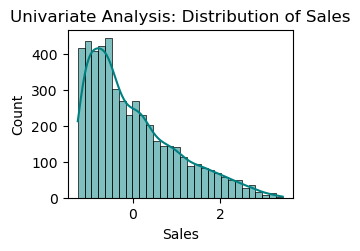

In [35]:
plt.subplot(2, 2, 1)
sns.histplot(df['Sales'], kde=True, color='teal')
plt.title('Univariate Analysis: Distribution of Sales')

## Bivariate Analysis

C:\Users\hp\AppData\Local\Temp\ipykernel_13352\2262729685.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Category', y='Profit', data=df, palette='Set2')


Text(0.5, 1.0, 'Bivariate Analysis: Profit by Category')

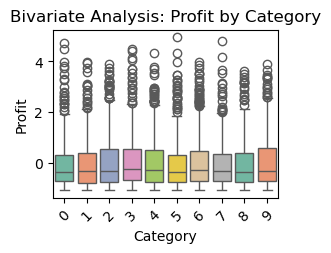

In [36]:
plt.subplot(2, 2, 2)
sns.boxplot(x='Category', y='Profit', data=df, palette='Set2')
plt.xticks(rotation=45)
plt.title('Bivariate Analysis: Profit by Category')

## Visualizations with Insights (Not limited to, as per applicability of your dataset)

### Histogram 

<Axes: >

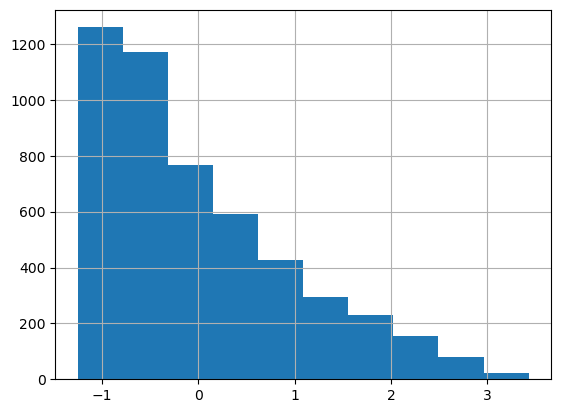

In [37]:
df['Sales'].hist()

### BoxPlot

<Axes: ylabel='Profit'>

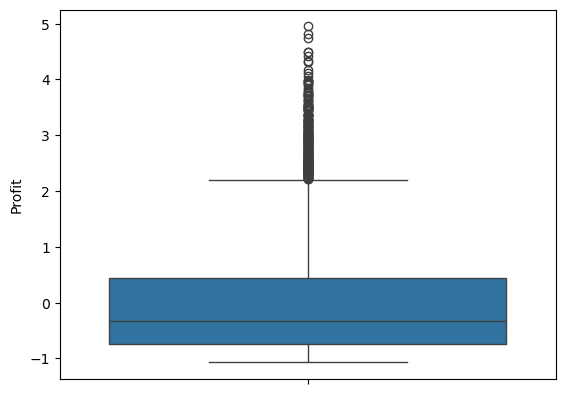

In [38]:
sns.boxplot(df['Profit'])

### ScatterPlot

<Axes: xlabel='Sales', ylabel='Profit'>

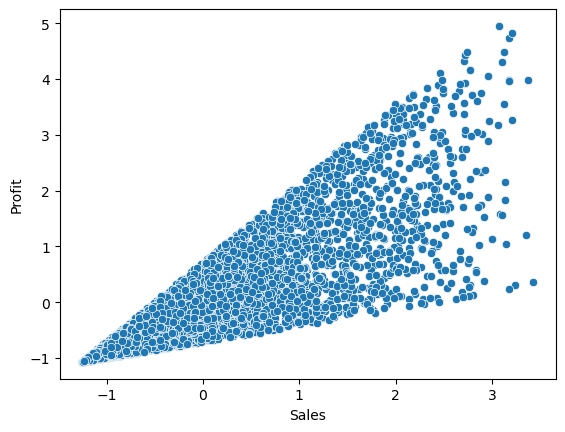

In [40]:
sns.scatterplot(x='Sales', y='Profit', data=df)

Text(0.5, 1.0, 'Insight: Sales vs Profit Relationship')

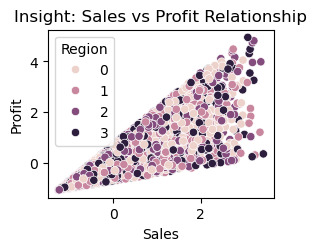

In [41]:
plt.subplot(2, 2, 3)
sns.scatterplot(x='Sales', y='Profit', data=df, hue='Region', alpha=1)
plt.title('Insight: Sales vs Profit Relationship')

## MatPlot

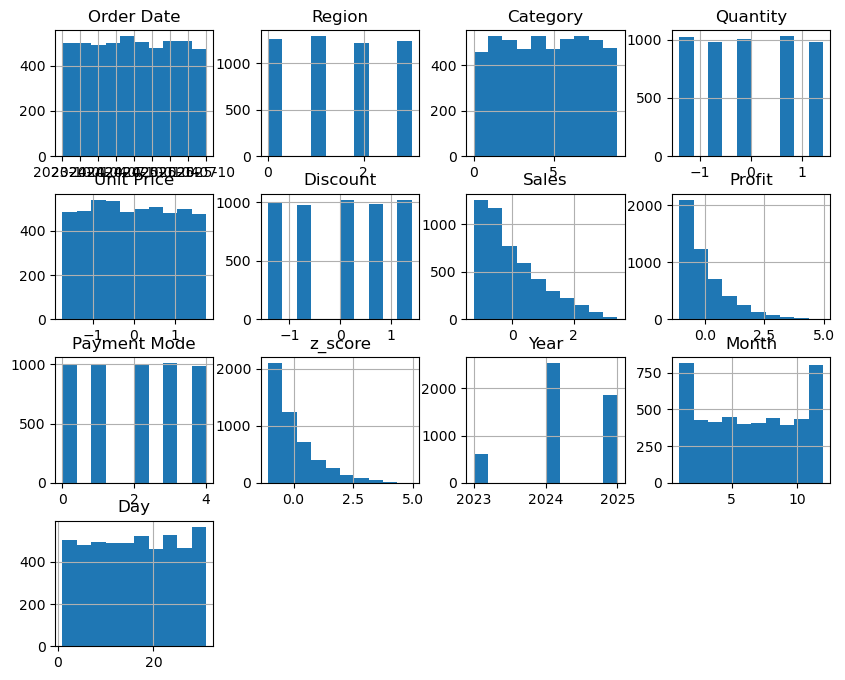

In [42]:
df.hist(figsize=(10,8))
plt.show()

### HeatMap

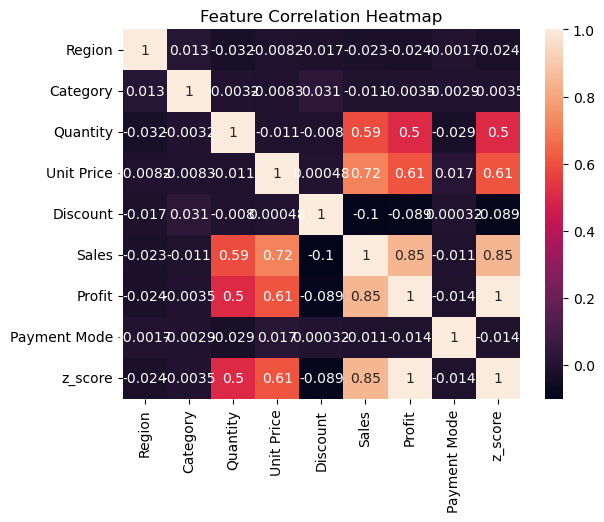

In [43]:
numeric_df = df.select_dtypes(include=['int64', 'float64'])
sns.heatmap(numeric_df.corr(), annot=True)
plt.title('Feature Correlation Heatmap')
plt.show()

<Axes: >

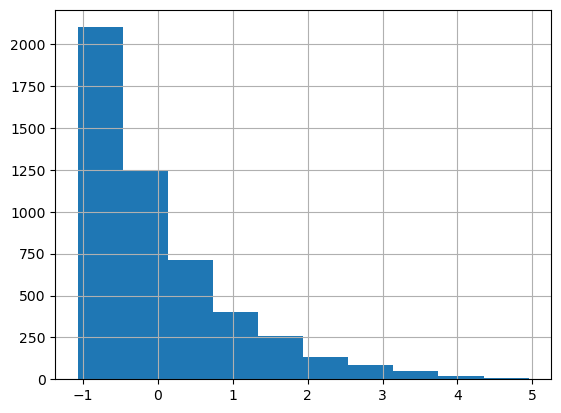

In [44]:
df['Profit'].hist()

<Axes: >

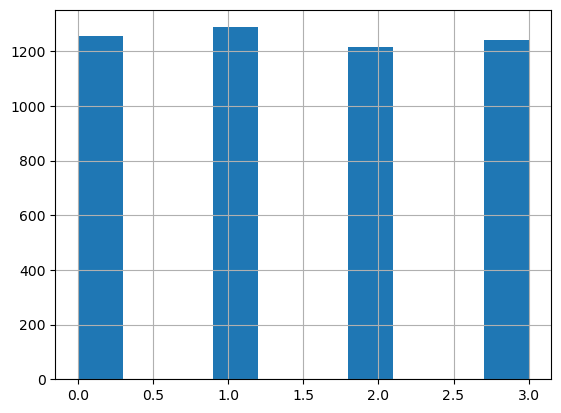

In [45]:
df['Region'].hist()

<Axes: >

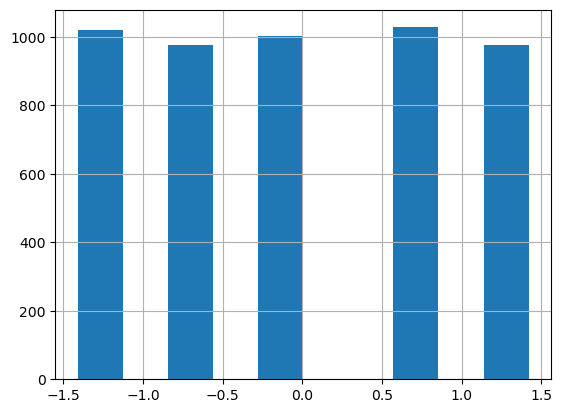

In [46]:
df['Quantity'].hist()

# Conclusion

The data analysis process has been successful in converting unstructured transactional data into structured data that can be analyzed effectively. With the help of the data science libraries in Python, namely Pandas, Scikit-Learn, and Seaborn, we have derived the essential metrics affecting the performance of an e-commerce business.